In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import re


def compute_pareto_front(x, y, direction='upper_right'):
    """
    Compute the Pareto front for a set of 2D points.
    
    direction: which corner is 'best'
        'upper_right' => maximize both x and y
        'upper_left'  => minimize x, maximize y
    
    Returns (is_pareto mask, points array).
    """
    points = np.column_stack([x, y])
    
    if direction == 'upper_right':
        is_pareto = np.ones(len(points), dtype=bool)
        for i, p in enumerate(points):
            for j, q in enumerate(points):
                if i != j and q[0] >= p[0] and q[1] >= p[1] and (q[0] > p[0] or q[1] > p[1]):
                    is_pareto[i] = False
                    break
    elif direction == 'upper_left':
        is_pareto = np.ones(len(points), dtype=bool)
        for i, p in enumerate(points):
            for j, q in enumerate(points):
                if i != j and q[0] <= p[0] and q[1] >= p[1] and (q[0] < p[0] or q[1] > p[1]):
                    is_pareto[i] = False
                    break
    else:
        raise ValueError(f"Unknown direction: {direction}")

    return is_pareto, points


def plot_adapter_pareto_panels(
    merged_mmlu, merged_bigbench,
    model, task,
    neg_shift_col='negative_shift_score',
    task_acc_col='accuracy',
    mmlu_col='mmlu_acc',
    bigbench_col='mean_accuracy',
    figsize=(18, 5),
    save_path=None,
    dpi=150
):
    """
    For each adapter type, create a 1x3 figure:
      [Task Acc vs Neg Shift] [Task Acc vs MMLU] [Task Acc vs BigBench]
    Each panel has points colored by LR, Pareto front line, and rank annotations.
    Pareto front values are printed to console.
    """
    task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
    
    adapters_mmlu = set(merged_mmlu['adapter_type'].unique()) if not merged_mmlu.empty else set()
    adapters_bb = set(merged_bigbench['adapter_type'].unique()) if not merged_bigbench.empty else set()
    all_adapters = sorted(adapters_mmlu | adapters_bb)

    adapter_display = {
        'lora': 'LoRA',
        'dora': 'DoRA',
        'uiortholora': 'UIorthoLoRA',
        'vera': 'VeRA',
        'unknown': 'Unknown'
    }

    # Global LR range for consistent colorbar
    all_lrs = pd.concat([
        merged_mmlu['lr'].dropna() if not merged_mmlu.empty else pd.Series(dtype=float),
        merged_bigbench['lr'].dropna() if not merged_bigbench.empty else pd.Series(dtype=float),
    ])
    if all_lrs.empty or all_lrs.min() <= 0:
        norm = None
    else:
        norm = colors.LogNorm(vmin=all_lrs.min(), vmax=all_lrs.max())
    cmap = plt.cm.viridis

    for adapter in all_adapters:
        # Use GridSpec: 3 equal plot columns + 1 narrow colorbar column
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
        axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
        cbar_ax = fig.add_subplot(gs[0, 3])

        display_name = adapter_display.get(adapter, adapter)
        fig.suptitle(
            f'{display_name} — {task_label} on {model}',
            fontsize=16, fontweight='bold', y=1.02
        )

        print(f"\n{'='*60}")
        print(f"  PARETO FRONT: {display_name} — {task_label} on {model}")
        print(f"{'='*60}")

        # Determine neg_shift source
        if neg_shift_col in merged_mmlu.columns:
            src_neg = merged_mmlu
        elif neg_shift_col in merged_bigbench.columns:
            src_neg = merged_bigbench
        else:
            src_neg = pd.DataFrame()

        neg_sub = src_neg[src_neg['adapter_type'] == adapter].dropna(
            subset=[neg_shift_col, task_acc_col, 'lr']
        ) if not src_neg.empty else pd.DataFrame()

        mmlu_sub = merged_mmlu[merged_mmlu['adapter_type'] == adapter].dropna(
            subset=[mmlu_col, task_acc_col, 'lr']
        ) if not merged_mmlu.empty else pd.DataFrame()

        bb_sub = merged_bigbench[merged_bigbench['adapter_type'] == adapter].dropna(
            subset=[bigbench_col, task_acc_col, 'lr']
        ) if not merged_bigbench.empty else pd.DataFrame()

        panel_configs = [
            {
                'ax': axes[0], 'data': neg_sub,
                'x_col': neg_shift_col, 'y_col': task_acc_col,
                'x_label': 'Negative Shift (forgetting)',
                'y_label': f'{task_label} Accuracy',
                'pareto_dir': 'upper_left',
                'title': 'vs Negative Shift'
            },
            {
                'ax': axes[1], 'data': mmlu_sub,
                'x_col': mmlu_col, 'y_col': task_acc_col,
                'x_label': 'MMLU Accuracy',
                'y_label': f'{task_label} Accuracy',
                'pareto_dir': 'upper_right',
                'title': 'vs MMLU'
            },
            {
                'ax': axes[2], 'data': bb_sub,
                'x_col': bigbench_col, 'y_col': task_acc_col,
                'x_label': 'BigBench Accuracy',
                'y_label': f'{task_label} Accuracy',
                'pareto_dir': 'upper_right',
                'title': 'vs BigBench'
            },
        ]

        sc = None
        for cfg in panel_configs:
            ax = cfg['ax']
            data = cfg['data']

            if data.empty:
                ax.set_title(cfg['title'], fontsize=13)
                ax.set_xlabel(cfg['x_label'], fontsize=11)
                ax.set_ylabel(cfg['y_label'], fontsize=11)
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=12, color='gray')
                ax.grid(True, linestyle='--', alpha=0.4)
                print(f"\n  [{cfg['title']}] No data available")
                continue

            x = data[cfg['x_col']].values
            y = data[cfg['y_col']].values
            lr = data['lr'].values
            ranks = data['rank'].values if 'rank' in data.columns else None
            names = data['merge_key'].values if 'merge_key' in data.columns else None

            # Scatter
            sc = ax.scatter(
                x, y, c=lr, norm=norm, cmap=cmap,
                s=100, alpha=0.85, edgecolors='k', linewidth=0.5, zorder=3
            )
            

            # Pareto front
            if len(x) >= 2:
                is_pareto, points = compute_pareto_front(x, y, direction=cfg['pareto_dir'])
                pareto_points = points[is_pareto]
                order = np.argsort(pareto_points[:, 0])
                px, py = pareto_points[order, 0], pareto_points[order, 1]

                if len(px) >= 2:
                    ax.plot(px, py, 'r--', linewidth=2, alpha=0.7, label='Pareto front', zorder=2)
                ax.scatter(px, py, facecolors='none', edgecolors='red',
                           s=180, linewidths=1.8, zorder=5)

                # Print Pareto values
                pareto_indices = np.where(is_pareto)[0]
                print(f"\n  [{cfg['title']}] Pareto front ({len(pareto_indices)} points):")
                print(f"  {'Name':<45} {'Rank':>5} {'LR':>10} {cfg['x_col']:>15} {cfg['y_col']:>15}")
                print(f"  {'-'*95}")
                for idx in pareto_indices:
                    name_str = names[idx] if names is not None else '—'
                    rank_str = f"r{int(ranks[idx])}" if ranks is not None else '—'
                    print(f"  {name_str:<45} {rank_str:>5} {lr[idx]:>10.1e} {x[idx]:>15.4f} {y[idx]:>15.4f}")

            ax.set_title(cfg['title'], fontsize=13)
            ax.set_xlabel(cfg['x_label'], fontsize=11)
            ax.set_ylabel(cfg['y_label'], fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.legend(fontsize=9, loc='best')

        # Shared colorbar in dedicated axes
        if sc and norm:
            fig.colorbar(sc, cax=cbar_ax, label='Learning Rate (log scale)')
        else:
            cbar_ax.set_visible(False)

        if save_path:
            import os
            os.makedirs(save_path, exist_ok=True)
            fname = f"{save_path}/{adapter}_{model}_{task}_pareto.pdf"
            fig.savefig(fname, dpi=dpi, bbox_inches='tight')
            print(f"\n  Saved: {fname}")

        plt.show()


def plot_all_configs(merged_mmlu, merged_bigbench, model, task,
                     neg_shift_col='negative_shift_score', save_path=None):
    """Drop-in replacement: call this instead of plot_config."""
    plot_adapter_pareto_panels(
        merged_mmlu, merged_bigbench,
        model=model, task=task,
        neg_shift_col=neg_shift_col,
        save_path=save_path
    )

In [27]:
def extract_metadata(df, name_col='model_path'):
    df = df.copy()
    
    if 'peft_method' in df.columns:
        df['adapter_type'] = df['peft_method'].fillna('')
    else:
        df['adapter_type'] = ''

    def get_adapter(row):
        val = str(row.get('adapter_type', '')).lower()
        name = str(row[name_col]).lower()
        if val in ['lora', 'vera', 'uiortholora', 'dora']:
            return val
        if 'uiortho' in name: return 'uiortholora'
        if 'dora' in name: return 'dora'
        if 'vera' in name: return 'vera'
        if 'lora' in name: return 'lora'
        return 'unknown'

    df['adapter_type'] = df.apply(get_adapter, axis=1)

    def get_lr(row):
        if 'learning_rate' in row and pd.notnull(row['learning_rate']):
            return float(row['learning_rate'])
        if 'lr' in row and pd.notnull(row['lr']):
            try:
                return float(row['lr'])
            except (ValueError, TypeError):
                pass
        match = re.search(r'lr([\de.-]+)', str(row[name_col]))
        if match:
            try: return float(match.group(1))
            except: return np.nan
        return np.nan

    df['lr'] = df.apply(get_lr, axis=1)

    # Uses (?:s|sv) and (?:v|svec) to catch both naming conventions without capturing those letters
    regex_pattern = r'_(?:s|sv)(\d+)_(?:v|svec)(\d+)'

    def get_svals(row):
        m = re.search(regex_pattern, str(row[name_col]))
        return int(m.group(1)) if m else np.nan

    def get_svecs(row):
        m = re.search(regex_pattern, str(row[name_col]))
        return int(m.group(2)) if m else np.nan

    df['svals'] = df.apply(get_svals, axis=1)
    df['svecs'] = df.apply(get_svecs, axis=1)

    # Rank: svals for uiortholora, _r for others
    def get_rank(row):
        if 'rank' in row and pd.notnull(row['rank']):
            try: return int(float(row['rank']))
            except (ValueError, TypeError): pass
            
        name = str(row[name_col])
        
        # Check UIorthoLoRA pattern first
        m_sv = re.search(regex_pattern, name)
        if m_sv: return int(m_sv.group(1))
        
        # Check standard LoRA/VeRA _r pattern
        m_r = re.search(r'_r(\d+)', name)
        if m_r: return int(m_r.group(1))
        
        return 0

    df['rank'] = df.apply(get_rank, axis=1)
    
    return df

def align_and_merge(df_task, df_general, general_name_col='model_name', 
                    task_name_col='raw_adapter_name', suffixes=('_task', '_gen')):
    """
    Aligns task results with general benchmark results (MMLU, BigBench, etc.)
    by extracting the adapter name from potentially nested path columns.
    """
    df_general = df_general.copy()
    
    # Strip to just the adapter name (last path segment, remove 'models/' prefix)
    df_general['merge_key'] = (
        df_general[general_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    # Also normalize task side in case it has paths too
    df_task = df_task.copy()
    df_task['merge_key'] = (
        df_task[task_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    merged = pd.merge(
        df_task,
        df_general,
        on='merge_key',
        suffixes=suffixes
    )
    
    merged = extract_metadata(merged, name_col='merge_key')
    
    print(f"Merged rows: {len(merged)} "
          f"(task: {len(df_task)}, general: {len(df_general)}, "
          f"unmatched task: {len(df_task) - len(merged)})")
    
    return merged

In [28]:
def load_and_merge(model, task, threshold='0.8', filter_fn=None):
    """
    Load task, MMLU, and BigBench data for a given model/task config
    and return merged DataFrames ready for plotting.
    
    Parameters:
        model: 'gemma-12b' or 'llama-3b'
        task: 'triviaqa' or 'hotpotqa'
        threshold: threshold string (default '0.8')
        filter_fn: optional function to filter the merged DataFrames
    
    Returns:
        (merged_mmlu, merged_bigbench) tuple of DataFrames
    """
    file_path = f'adapters_results/{task}/threshold_{threshold}/{model}.csv'
    mmlu_path = f'adapters_results/{task}/mmlu_summary.csv'
    bigbench_path = f'adapters_results/{task}/bigbench_summary.csv'

    df_task = pd.read_csv(file_path)
    df_mmlu = pd.read_csv(mmlu_path)
    df_bigbench = pd.read_csv(bigbench_path)

    print(f"=== {model} / {task} ===")
    merged_mmlu = align_and_merge(df_task, df_mmlu, general_name_col='model_name')
    merged_bigbench = align_and_merge(df_task, df_bigbench, general_name_col='model_path')

    if filter_fn:
        merged_mmlu = filter_fn(merged_mmlu)
        merged_bigbench = filter_fn(merged_bigbench)
        print(f"After filter: MMLU={len(merged_mmlu)}, BigBench={len(merged_bigbench)}")

    return merged_mmlu, merged_bigbench

In [29]:
lora_r1_plus_others = lambda df: df[(df['adapter_type'] != 'lora') | (df['rank'] == 1)]
final_filter = lambda df: df
# final_filter = lora_r1_plus_others

# Load all 4 configs
gemma_trivia_mmlu, gemma_trivia_bb = load_and_merge('gemma-12b', 'triviaqa', filter_fn=final_filter)
gemma_hotpot_mmlu, gemma_hotpot_bb = load_and_merge('gemma-12b', 'hotpotqa', filter_fn=final_filter)
llama_trivia_mmlu, llama_trivia_bb = load_and_merge('llama-3b', 'triviaqa', filter_fn=final_filter)
llama_hotpot_mmlu, llama_hotpot_bb = load_and_merge('llama-3b', 'hotpotqa', filter_fn=final_filter)

=== gemma-12b / triviaqa ===
Merged rows: 123 (task: 107, general: 189, unmatched task: -16)
Merged rows: 128 (task: 107, general: 195, unmatched task: -21)
After filter: MMLU=123, BigBench=128
=== gemma-12b / hotpotqa ===
Merged rows: 199 (task: 180, general: 315, unmatched task: -19)
Merged rows: 203 (task: 180, general: 323, unmatched task: -23)
After filter: MMLU=199, BigBench=203
=== llama-3b / triviaqa ===
Merged rows: 97 (task: 92, general: 189, unmatched task: -5)
Merged rows: 98 (task: 92, general: 195, unmatched task: -6)
After filter: MMLU=97, BigBench=98
=== llama-3b / hotpotqa ===
Merged rows: 155 (task: 123, general: 315, unmatched task: -32)
Merged rows: 160 (task: 123, general: 323, unmatched task: -37)
After filter: MMLU=155, BigBench=160



  PARETO FRONT: DoRA — HotPot on gemma-12b

  [vs Negative Shift] Pareto front (14 points):
  Name                                           Rank         LR negative_shift_score        accuracy
  -----------------------------------------------------------------------------------------------
  dora_trAll_lora_r16_lr1e-4                      r16    1.0e-04       1546.1000          0.9932
  dora_trAll_lora_r16_lr1e-4                      r16    1.0e-04       1546.1000          0.9932
  dora_trAll_lora_r32_lr1e-4                      r32    1.0e-04       1515.5000          0.9929
  dora_trAll_lora_r32_lr1e-4                      r32    1.0e-04       1515.5000          0.9929
  dora_trAll_lora_r3_lr1e-4                        r3    1.0e-04       1510.3000          0.9918
  dora_trAll_lora_r3_lr1e-4                        r3    1.0e-04       1510.3000          0.9918
  dora_trAll_lora_r8_lr1e-4                        r8    1.0e-04       1461.2000          0.9916
  dora_trAll_lora_r8_lr1e-4 

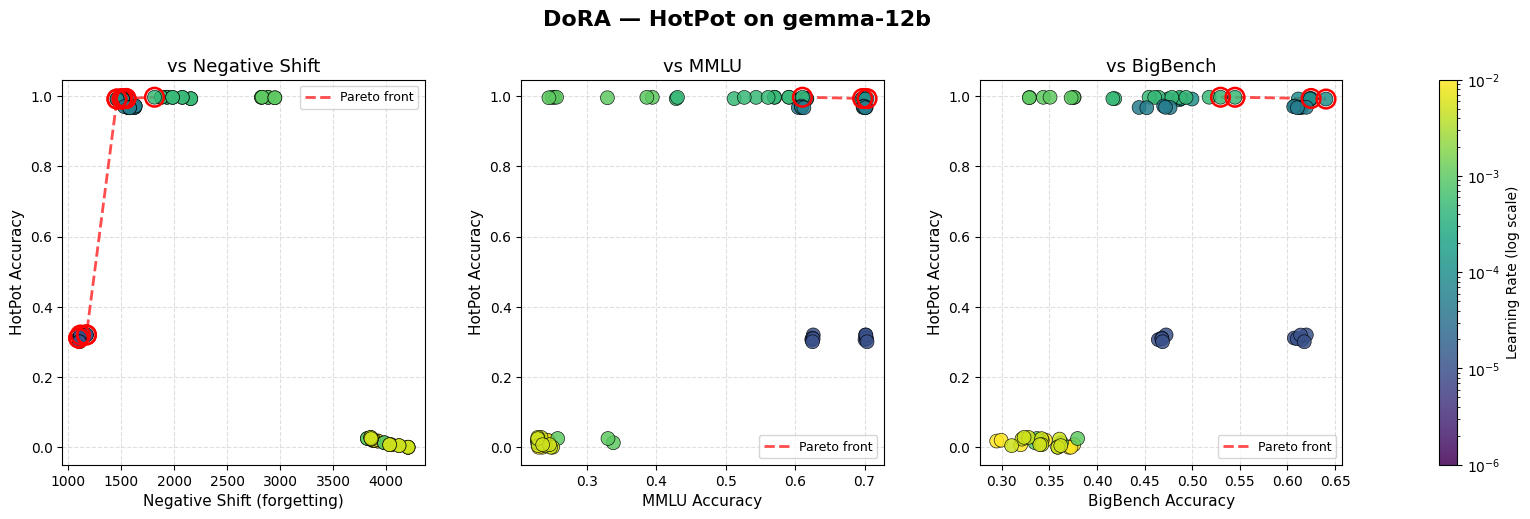


  PARETO FRONT: LoRA — HotPot on gemma-12b

  [vs Negative Shift] Pareto front (3 points):
  Name                                           Rank         LR negative_shift_score        accuracy
  -----------------------------------------------------------------------------------------------
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4    r3    1.0e-04       1564.5000          0.9961
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6    r3    1.0e-06        548.1000          0.1283
  google_gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5    r8    7.0e-05       1468.5000          0.9956

  [vs MMLU] Pareto front (5 points):
  Name                                           Rank         LR        mmlu_acc        accuracy
  -----------------------------------------------------------------------------------------------
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4    r3    1.0e-04          0.6911          0.9961
  google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6    r3    1.0e-06          0.7

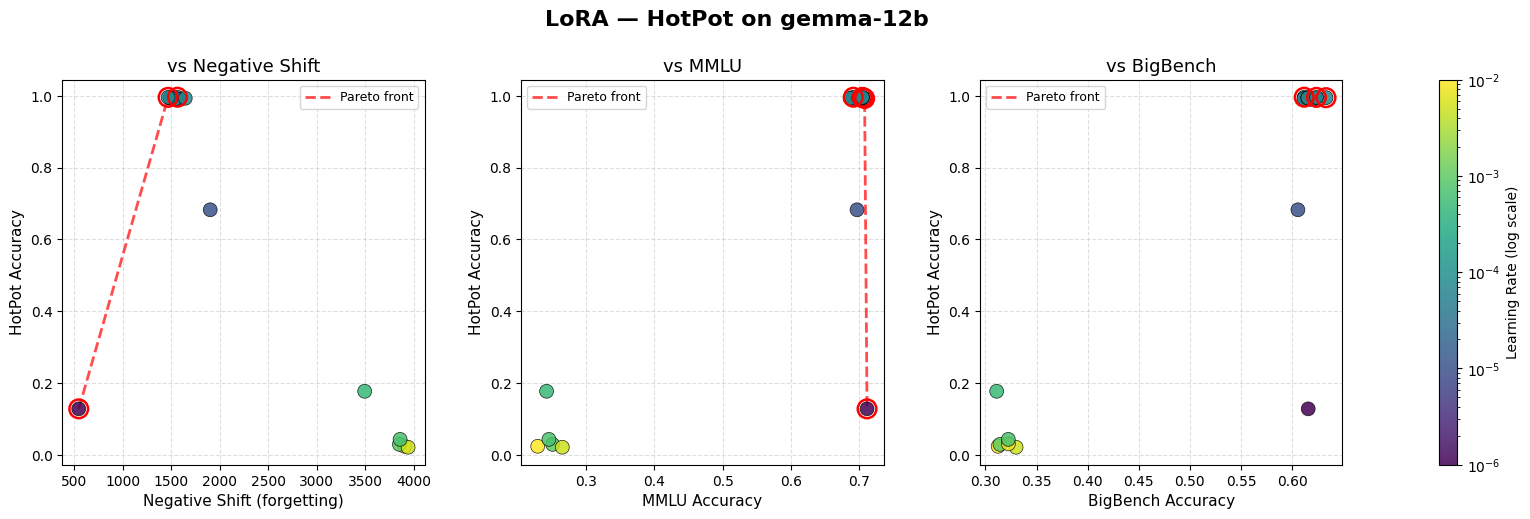


  PARETO FRONT: UIorthoLoRA — HotPot on gemma-12b

  [vs Negative Shift] Pareto front (13 points):
  Name                                           Rank         LR negative_shift_score        accuracy
  -----------------------------------------------------------------------------------------------
  google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-5 r1024    5.0e-05        444.3000          0.0000
  google_gemma-3-12b-it_uiortholora_trAll_s1024_v10_lr1e-2 r1024    1.0e-02       1666.1000          0.9956
  google_gemma-3-12b-it_uiortholora_trAll_s256_v3_lr1e-2  r256    1.0e-02       1719.4000          0.9959
  google_gemma-3-12b-it_uiortholora_trAll_s512_v128_lr1e-3  r512    1.0e-03        924.5000          0.2783
  google_gemma-3-12b-it_uiortholora_trAll_s512_v256_lr1e-3  r512    1.0e-03        978.6000          0.2972
  google_gemma-3-12b-it_uiortholora_trAll_s512_v32_lr1e-3  r512    1.0e-03        799.0000          0.2451
  google_gemma-3-12b-it_uiortholora_trAll_s5

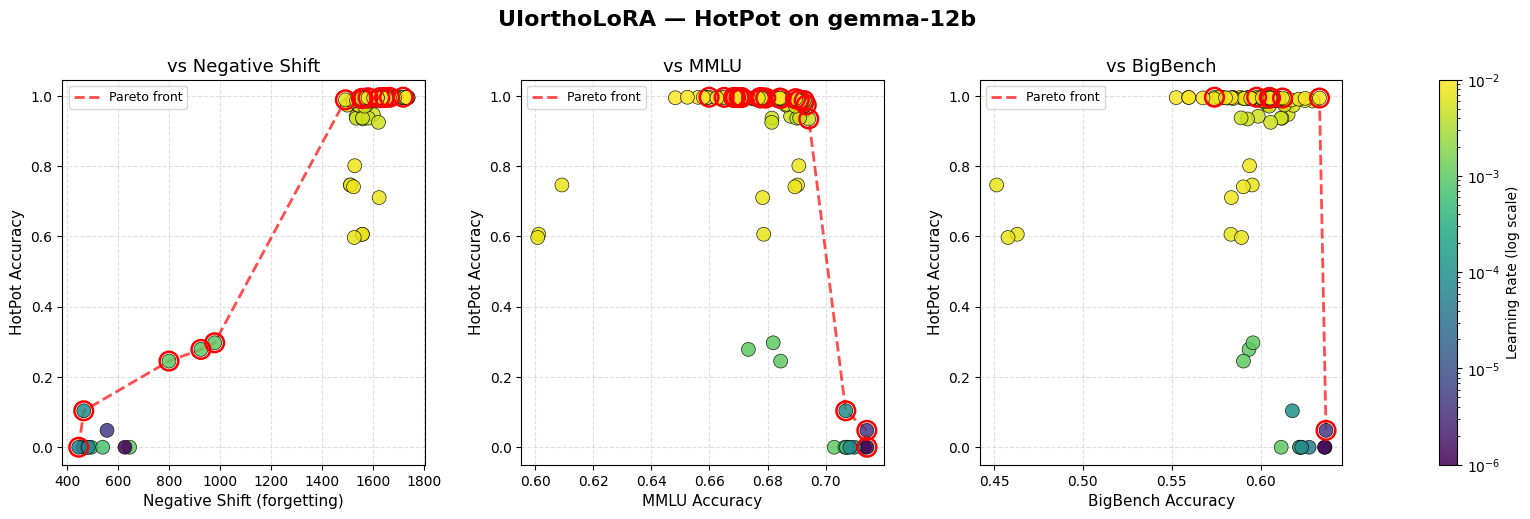


  PARETO FRONT: VeRA — HotPot on gemma-12b

  [vs Negative Shift] Pareto front (9 points):
  Name                                           Rank         LR negative_shift_score        accuracy
  -----------------------------------------------------------------------------------------------
  google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-2 r1024    1.0e-02       1979.1000          0.9958
  google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-3 r1024    1.0e-03       1110.2000          0.3671
  google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4 r1024    1.0e-04        486.1000          0.1090
  google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-5 r1024    1.0e-05        449.9000          0.0573
  google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-3 r1024    5.0e-03       1623.7000          0.9829
  google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-4 r1024    5.0e-04        612.7000          0.1804
  google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-5 r1024    5.0e-05        482.1000          0

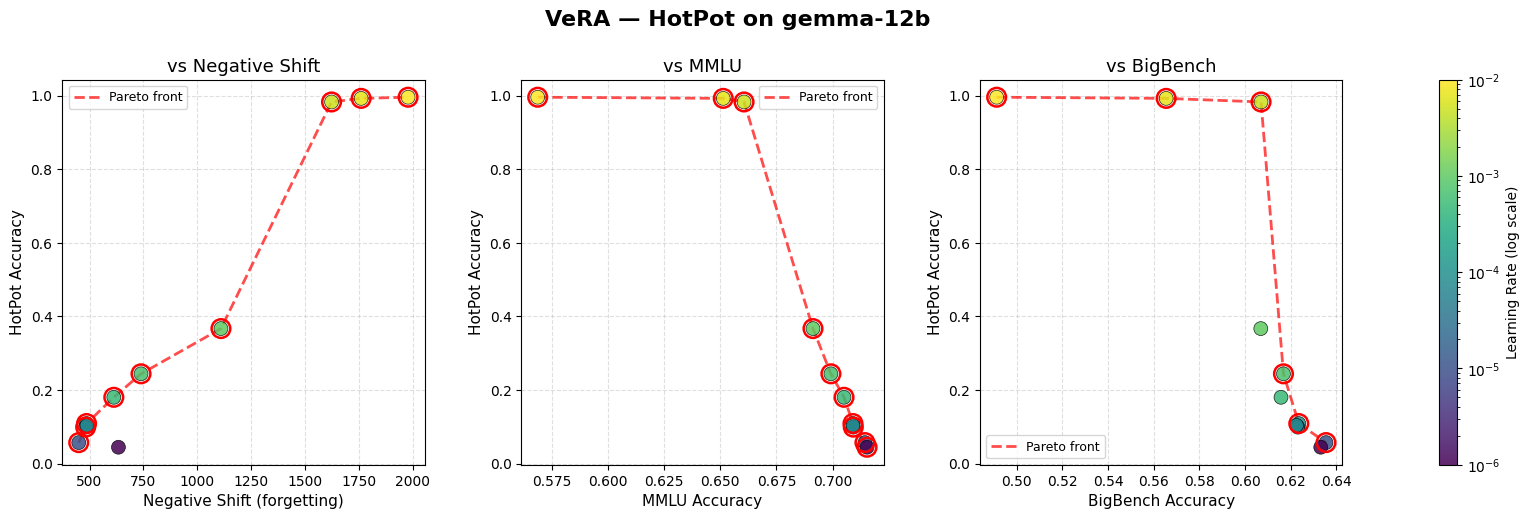

In [30]:
plot_all_configs(gemma_hotpot_mmlu, gemma_hotpot_bb, 'gemma-12b', 'hotpot', 'negative_shift_score')

In [31]:
f = lambda df: df[
    (df['adapter_type'] == 'vera') | 
    ((df['adapter_type'] == 'uiortholora') & (df['svecs'] == 0.0))
    # (df['adapter_type'] == 'lora') & (df['rank'] == 1) |
    # (df['adapter_type'] == 'dora') & (df['rank'] == 1))
]

In [32]:
def plot_combined_comparison(
    merged_mmlu, merged_bigbench,
    model, task,
    neg_shift_col='negative_shift_score',
    task_acc_col='accuracy',
    mmlu_col='mmlu_acc',
    bigbench_col='mean_accuracy',
    figsize=(18, 5)
):
    """
    Plots multiple adapter types on the same 1x3 panel for direct comparison.
    Distinguishes adapters by marker shape while keeping LR as the color.
    """
    task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
    
    # Setup Figure
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cbar_ax = fig.add_subplot(gs[0, 3])
    
    fig.suptitle(f'VeRA vs UIorthoLoRA (svecs=0) — {task_label} on {model}', 
                 fontsize=16, fontweight='bold', y=1.02)

    # Global LR range for consistent colorbar
    all_lrs = pd.concat([merged_mmlu['lr'].dropna(), merged_bigbench['lr'].dropna()])
    if all_lrs.empty or all_lrs.min() <= 0:
        norm = None
    else:
        norm = colors.LogNorm(vmin=all_lrs.min(), vmax=all_lrs.max())
    cmap = plt.cm.viridis

    # Define how each adapter should look
    style_map = {
        'vera': {'marker': 'o', 'label': 'VeRA', 'line': '-'},
        'uiortholora': {'marker': '^', 'label': 'UIorthoLoRA (svec=0)', 'line': '--'}
    }

    # Panel Configurations
    panel_configs = [
        {'ax': axes[0], 'src': merged_mmlu if neg_shift_col in merged_mmlu.columns else merged_bigbench,
         'x_col': neg_shift_col, 'y_col': task_acc_col, 'pareto_dir': 'upper_left',
         'x_label': 'Negative Shift (forgetting)', 'title': 'vs Negative Shift'},
        {'ax': axes[1], 'src': merged_mmlu,
         'x_col': mmlu_col, 'y_col': task_acc_col, 'pareto_dir': 'upper_right',
         'x_label': 'MMLU Accuracy', 'title': 'vs MMLU'},
        {'ax': axes[2], 'src': merged_bigbench,
         'x_col': bigbench_col, 'y_col': task_acc_col, 'pareto_dir': 'upper_right',
         'x_label': 'BigBench Accuracy', 'title': 'vs BigBench'}
    ]

    sc = None # Store scatter plot for colorbar

    for cfg in panel_configs:
        ax = cfg['ax']
        data_source = cfg['src']
        
        ax.set_title(cfg['title'], fontsize=13)
        ax.set_xlabel(cfg['x_label'], fontsize=11)
        ax.set_ylabel(f'{task_label} Accuracy', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)
        
        if data_source.empty or cfg['x_col'] not in data_source.columns:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, color='gray')
            continue

        # Plot each adapter type on the SAME axis
        for adapter in data_source['adapter_type'].unique():
            style = style_map.get(adapter, {'marker': 's', 'label': adapter, 'line': ':'})
            
            sub_data = data_source[data_source['adapter_type'] == adapter].dropna(subset=[cfg['x_col'], cfg['y_col'], 'lr'])
            if sub_data.empty: continue
                
            x = sub_data[cfg['x_col']].values
            y = sub_data[cfg['y_col']].values
            lr = sub_data['lr'].values
            
            # Scatter
            sc = ax.scatter(x, y, c=lr, norm=norm, cmap=cmap, marker=style['marker'],
                            s=100, alpha=0.85, edgecolors='k', linewidth=0.5, zorder=3, label=style['label'])
            
            # Pareto front
            if len(x) >= 2:
                is_pareto, points = compute_pareto_front(x, y, direction=cfg['pareto_dir'])
                pareto_points = points[is_pareto]
                order = np.argsort(pareto_points[:, 0])
                px, py = pareto_points[order, 0], pareto_points[order, 1]
                
                if len(px) >= 2:
                    # Draw a line connecting the pareto points for this specific adapter
                    ax.plot(px, py, linestyle=style['line'], linewidth=2, alpha=0.7, color='gray', zorder=2)
                
                # Highlight the pareto points
                ax.scatter(px, py, facecolors='none', edgecolors='red', marker=style['marker'],
                           s=180, linewidths=1.8, zorder=5)

        # Fix legend to show shapes without the color map interfering
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if by_label:
            # Create proxy artists for the legend so they show up as black shapes
            from matplotlib.lines import Line2D
            legend_elements = [Line2D([0], [0], marker=style_map[lbl.split()[0].lower()]['marker'], color='w', 
                                      label=lbl, markerfacecolor='k', markersize=10) 
                               for lbl in by_label.keys() if lbl.split()[0].lower() in style_map]
            ax.legend(handles=legend_elements, fontsize=9, loc='best')

    # Colorbar
    if sc and norm:
        fig.colorbar(sc, cax=cbar_ax, label='Learning Rate (log scale)')
    else:
        cbar_ax.set_visible(False)

    plt.show()

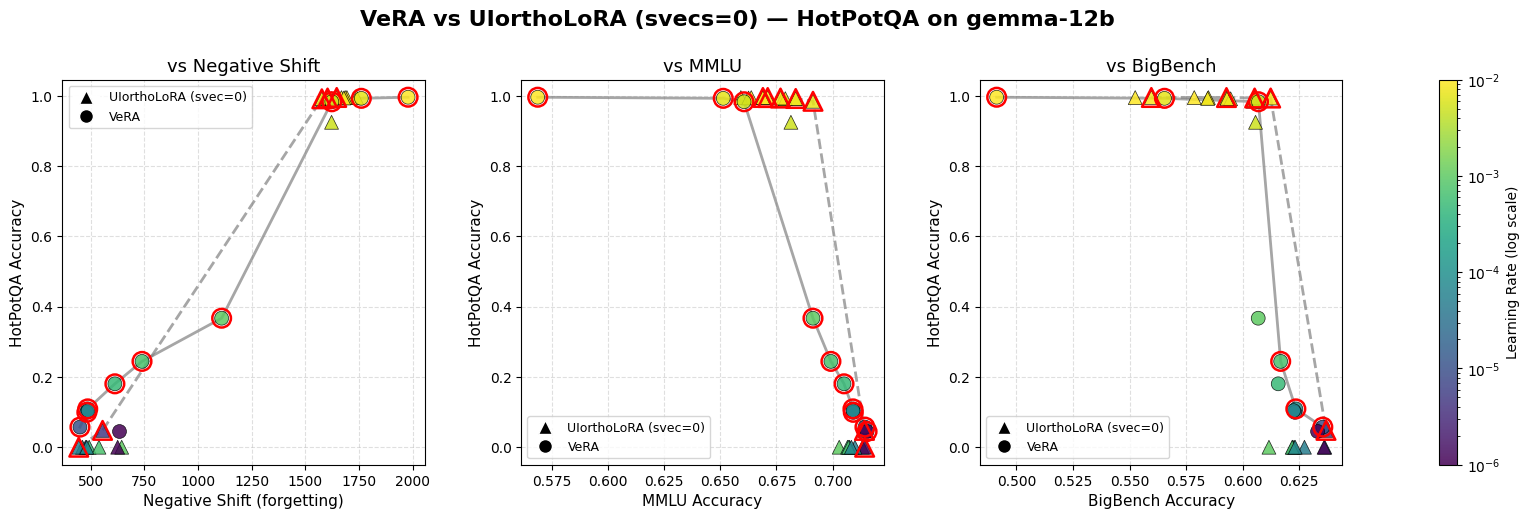

In [33]:
plot_combined_comparison(f(gemma_hotpot_mmlu), f(gemma_hotpot_bb), 'gemma-12b', 'hotpotqa', 
                 neg_shift_col='negative_shift_score')